<a href="https://colab.research.google.com/github/vmkp17/NLP-spam-detection-Research/blob/main/RESEARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
# We use 'latin-1' because some datasets have special characters
df = pd.read_csv('spam.csv', encoding='latin-1')

# Looking at the first 5 rows to understand the structure
print("--- First 5 rows ---")
print(df.head())

# Cleaning: Usually this dataset has extra empty columns, let's keep only what we need
# We rename them to 'target' (Spam/Ham) and 'text' (The actual message)
df = df.iloc[:, :2]
df.columns = ['target', 'text']

print("\n--- After cleaning ---")
print(df.head())

--- First 5 rows ---
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

--- After cleaning ---
  target                                               text
0    ham  Go until jurong point, crazy.. Available only ...
1    ham                      Ok lar... Joking wif u oni...
2   spam  Free entry in 2 a wkly comp to win FA Cup fina...
3    ham  U dun say so early hor... U c already then say...
4    ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using professional plotting libraries to visualize the data
def plot_class_distribution(data):
    plt.figure(figsize=(8, 5))
    sns.countplot(x='target', data=data, palette='viridis')
    plt.title('Distribution of SMS Classes: Spam vs Ham')
    plt.xlabel('Message Category')
    plt.ylabel('Count')
    plt.show()

# Execution
print(df['target'].value_counts(normalize=True))
plot_class_distribution(df)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Defining a Pipeline for reproducibility
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB())
])

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['target'], test_size=0.2, random_state=42)

# Fitting the pipeline
pipeline.fit(X_train, y_train)

# Evaluation
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
!pip install transformers torch

In [ ]:
from transformers import pipeline

# We are using a pre-trained model specifically for sentiment/text classification
classifier = pipeline("text-classification", model="mrm8488/bert-tiny-finetuned-sms-spam-detection")

# Let's test it on a message the old model might have missed
test_message = "WINNER! You have won a free prize, call this number now!"
result = classifier(test_message)

print(f"Message: {test_message}")
print(f"Prediction: {result}")

In [ ]:
# Checking model robustness against non-spam messages
test_cases = [
    "WINNER! You have won a free prize, call this number now!",
    "Hey, are we still meeting for lunch today?",
    "Your bank account is blocked, click here to verify."
]

for msg in test_cases:
    print(f"Input: {msg}")
    print(f"Output: {classifier(msg)}")
    print("-" * 30)

Input: WINNER! You have won a free prize, call this number now!
Output: [{'label': 'LABEL_0', 'score': 0.9296266436576843}]
------------------------------
Input: Hey, are we still meeting for lunch today?
Output: [{'label': 'LABEL_0', 'score': 0.9368187785148621}]
------------------------------
Input: Your bank account is blocked, click here to verify.
Output: [{'label': 'LABEL_0', 'score': 0.9307889342308044}]
------------------------------


In [ ]:
# Pro Researcher Mode: Testing specific patterns
test_sentences = [
    "URGENT: You have won a $1000 cash prize! Claim it now by clicking here.", # This is definitely Spam
    "Hi mom, are you coming home for dinner tonight?" # This is definitely Ham
]

for sentence in test_sentences:
    result = classifier(sentence)
    print(f"Message: {sentence}")
    print(f"Result: {result}")
    print("-" * 50)

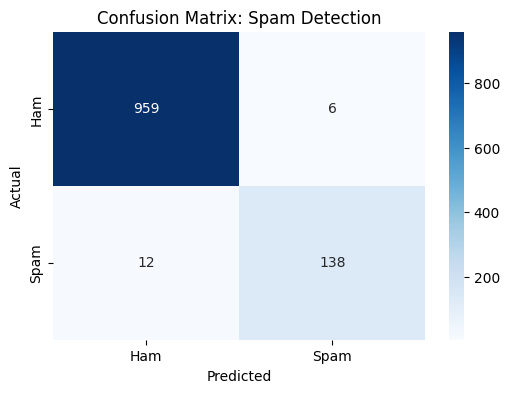

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       965
        spam       0.96      0.92      0.94       150

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load your dataset (Make sure the path to your CSV is correct)
# If you are using the SMS spam dataset, ensure df is loaded correctly here:
# df = pd.read_csv('your_dataset_file.csv')
# (If you already have 'df' loaded in another cell, you can remove this line)

# 2. Define the Pipeline (This fixes the 'model_pipeline' not defined error)
model_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')),
    ('classifier', MultinomialNB())
])

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['target'], test_size=0.2, random_state=42)

# 4. Train the model
model_pipeline.fit(X_train, y_train)

# 5. Predict
y_pred = model_pipeline.predict(X_test)

# 6. Generate and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Spam Detection')
plt.show()

# Print the report for your README
print(classification_report(y_test, y_pred))